In [57]:
import pandas as pd

# check df

In [1]:
import pandas as pd

dsc_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/FeCl3EthylGlyc14/2026-07-22/2026-07-22-DSC-FeCl3EthylGlyc-1-4.xls')
dsc_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/FeCl3EthylGlyc14/2026-07-22/2026-07-22-DSC-FeCl3EthylGlyc-1-4.xls', 
                          sheet_name="Ramp 10.00 °Cmin to 30.00 °C",
                          header =1
                          )
print(dsc_xl.sheet_names)
dsc_df.head()

['Details', 'Isothermal 5.0 min', 'Ramp 10.00 °Cmin to -80.00 °C', 'Ramp 10.00 °Cmin to 30.00 °C', 'Isothermal 5.0 min-2']


,Temperature,Heat Capacity (Normalized),Heat Flow (Normalized)
0,°C,J/(g.°C),W/g
1,-76.22,0,0.119109
2,-76.23,1.07071,0.119258
3,-76.24,1.07214,0.119357
4,-76.26,1.07349,0.119439


In [ ]:
import pandas as pd

dsc_xl = pd.ExcelFile('/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/FeCl3EthylGlyc14/2026-07-22/2026-07-22-DSC-FeCl3EthylGlyc-1-4.xls')

sheets = dsc_xl.sheet_names

for s in range(0, len(sheets)):
    sheet_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/FeCl3EthylGlyc14/2026-07-22/2026-07-22-DSC-FeCl3EthylGlyc-1-4.xls',
                             sheet_name = s, header = 1)
    


# extract data fxn

In [2]:

# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets)
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

# single plot

# multi plot

# plotting fxn

In [4]:
import pandas as pd
dsc_df = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/ZnCl2EthylGlyc14/2026-07-22/2026-07-22-DSC-ZnCl2EthylGlyc-1-4.xls')
dsc_df[15000:19000]

['Details', 'Isothermal 5.0 min', 'Ramp 10.00 °Cmin to -80.00 °C', 'Ramp 10.00 °Cmin to 30.00 °C', 'Isothermal 5.0 min-2']


,Temperature (°C),Heat Capacity (Normalized) (J/(g.°C)),Heat Flow (Normalized) (W/g),Source Sheet
15000,-2.65,3.13755,-0.500755,Ramp 10.00 °Cmin to 30.00 °C
15001,-2.63,3.13778,-0.500765,Ramp 10.00 °Cmin to 30.00 °C
15002,-2.62,3.13803,-0.500776,Ramp 10.00 °Cmin to 30.00 °C
15003,-2.60,3.13825,-0.500788,Ramp 10.00 °Cmin to 30.00 °C
15004,-2.58,3.13839,-0.500801,Ramp 10.00 °Cmin to 30.00 °C
...,...,...,...,...
18995,30.01,0.00000,0.003607,Isothermal 5.0 min-2
18996,30.01,0.00000,0.003608,Isothermal 5.0 min-2
18997,30.01,0.00000,0.003609,Isothermal 5.0 min-2
18998,30.01,0.00000,0.003614,Isothermal 5.0 min-2


In [6]:
dsc_dfs_and_details = {
            # path
                "dscpath": "/Users/mauriellenoto/Desktop/seager/ionicliquids/data/DSC/FeCl3EthylGlyc14/2026-07-22/2026-07-22-DSC-FeCl3EthylGlyc-1-4.xls",
            # steps
                "steps": ['Isothermal 5.0 min', 'Ramp 10.00 °Cmin to -80.00 °C', 'Ramp 10.00 °Cmin to 30.00 °C', 'Isothermal 5.0 min-2'],
            #  dates
                "dscdate": "2026-07-22",
            # details
                "chemical": "FeCl3 Ethylene Glycol",
                "ratio": "1:4",
                    }

['Details', 'Isothermal 5.0 min', 'Ramp 10.00 °Cmin to -80.00 °C', 'Ramp 10.00 °Cmin to 30.00 °C', 'Isothermal 5.0 min-2']


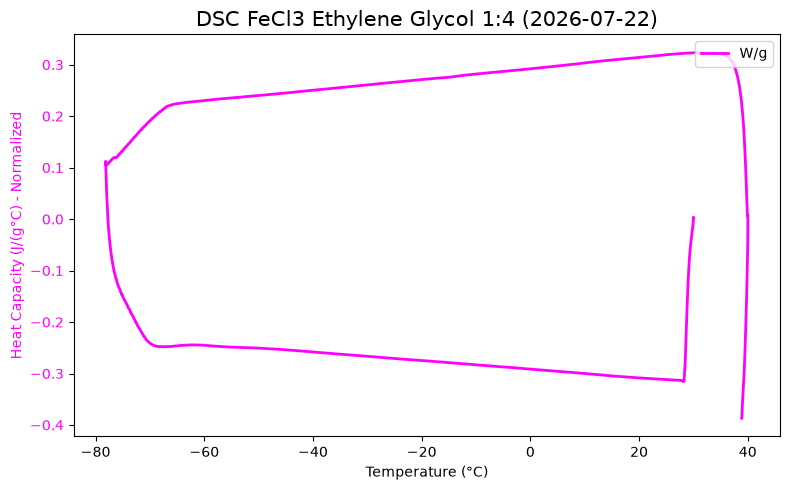

In [8]:
import matplotlib.pyplot as plt

def plot_dsc(dict, xlims=None, y1lims=None, y2lims=None):
    
    dsc_df = extract_data(dict["dscpath"])
    temp = dsc_df["Temperature (°C)"]
    hf_JgC = dsc_df["Heat Capacity (Normalized) (J/(g.°C))"]
    hf_Wg = dsc_df["Heat Flow (Normalized) (W/g)"]

    y1 = "magenta"
    y2 = "orange"

    fig, ax1 = plt.subplots(figsize = (8,5))

    heatflow_Wg = ax1.plot(temp, hf_Wg, color = y1, lw = 2, label = "W/g")
    ax1.set_xlabel("Temperature (°C)")
    if xlims:
        ax1.set_xlim(xlims)
    ax1.set_ylabel("Heat Capacity (J/(g°C) - Normalized", color = y1)
    if y1lims:
        ax1.set_ylim(y1lims)
    ax1.tick_params(axis='y', labelcolor = y1)

    plt.title(f"DSC {dict["chemical"]} {dict["ratio"]} ({dict["dscdate"]})", fontsize=15)
    plt.legend(loc = "upper right", 
               handles = [heatflow_Wg[0]])
    plt.tight_layout()
    plt.show()

dsc_plot = plot_dsc(dsc_dfs_and_details)
dsc_plot